In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


In [7]:
data = pd.read_csv("loan_data.csv")

print(data)

print("\nDataset Shape:")
print(data.shape)

print("\nDataset Info:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

   Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001    Male     Yes          2      Graduate           Yes   
1    LP002    Male     Yes          1      Graduate           Yes   
2    LP003  Female     Yes          1  Not Graduate            No   
3    LP004    Male      No          2  Not Graduate           Yes   
4    LP005  Female     Yes          0      Graduate           Yes   
5    LP006  Female      No          1  Not Graduate            No   
6    LP007    Male      No         3+  Not Graduate           Yes   
7    LP008  Female     Yes          1  Not Graduate           Yes   
8    LP009    Male      No         3+  Not Graduate            No   
9    LP010    Male     Yes         3+      Graduate            No   
10   LP011  Female      No          0  Not Graduate            No   
11   LP012  Female     Yes          1  Not Graduate           Yes   
12   LP013    Male      No          2      Graduate           Yes   
13   LP014    Male     Yes        

In [10]:
cat_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Credit_History',
    'Loan_Amount_Term'
]

for col in cat_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

# Fill numerical missing values with mean
num_columns = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount'
]

for col in num_columns:
    data[col] = data[col].fillna(data[col].mean())

print("\nMissing Values After Cleaning:")
print(data.isnull().sum())



Missing Values After Cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [11]:
encoder = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status',
    'Dependents'
]

for col in categorical_columns:
    data[col] = encoder.fit_transform(data[col])

print("\nEncoded Dataset:")
print(data.head())


Encoded Dataset:
  Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0   LP001       1        1           2          0              1   
1   LP002       1        1           1          0              1   
2   LP003       0        1           1          1              0   
3   LP004       1        0           2          1              1   
4   LP005       0        1           0          0              1   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             4286               6033         132               180   
1            11195               1628         294               240   
2             6552               1273         190               300   
3            13955               3763         143               360   
4            14665               2370         120               240   

   Credit_History  Property_Area  Loan_Status  
0               1              2            1  
1               1              0            1  
2 

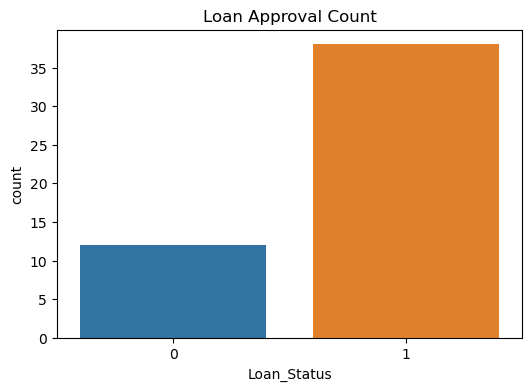

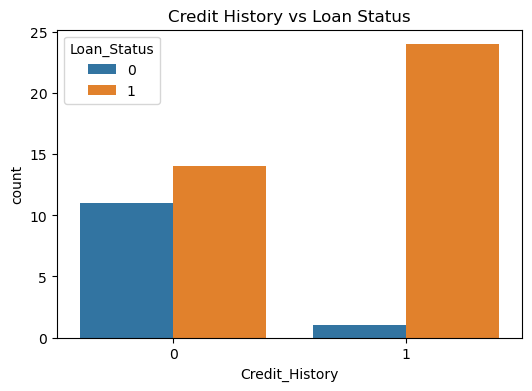

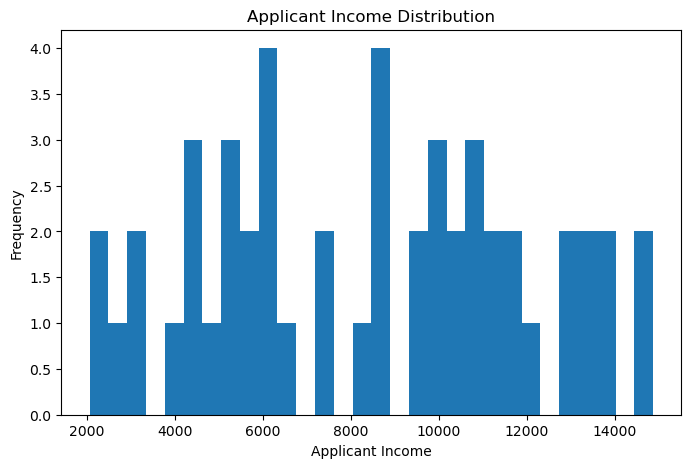

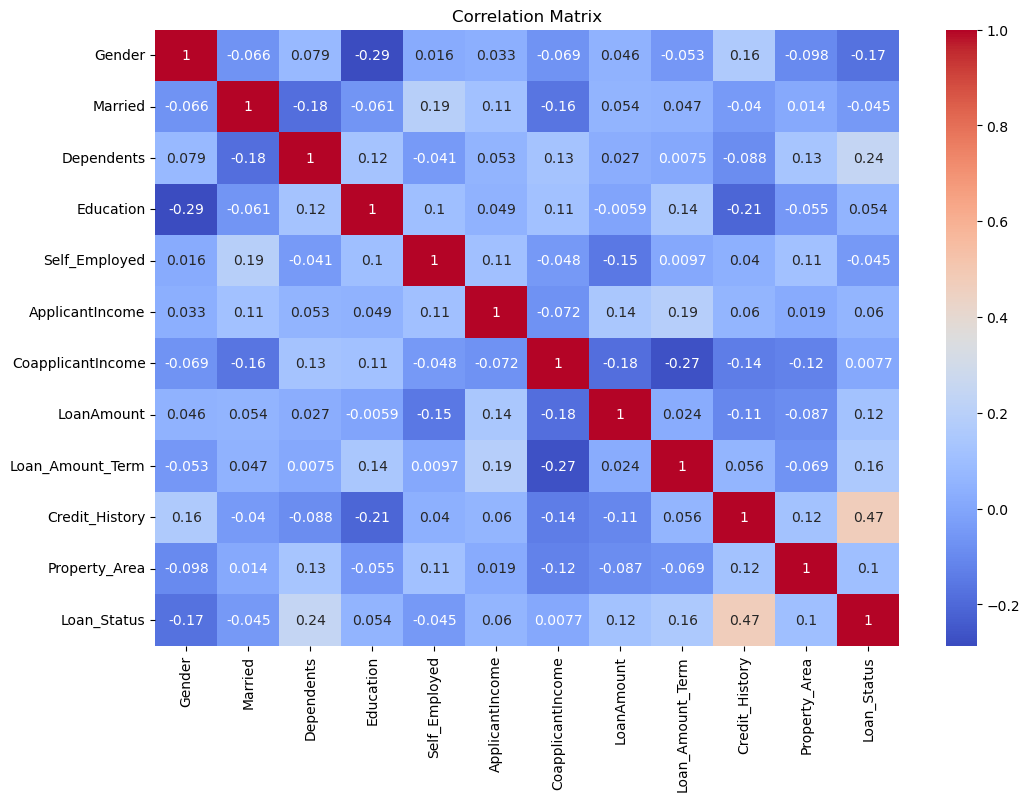

In [18]:
#Exploratory Data Analysis

# Loan Status Count
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=data)
plt.title("Loan Approval Count")
plt.show()

# Credit History vs Loan Status
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=data)
plt.title("Credit History vs Loan Status")
plt.show()
# Income Distribution

plt.figure(figsize=(8,5))

plt.hist(data['ApplicantIncome'], bins=30)

plt.title("Applicant Income Distribution")

plt.xlabel("Applicant Income")

plt.ylabel("Frequency")

plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [20]:
# Drop Loan_ID if present
if 'Loan_ID' in data.columns:
    data = data.drop('Loan_ID', axis=1)

# Features and Target
X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())



Features:
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        1           2          0              1             4286   
1       1        1           1          0              1            11195   
2       0        1           1          1              0             6552   
3       1        0           2          1              1            13955   
4       0        1           0          0              1            14665   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               6033         132               180               1   
1               1628         294               240               1   
2               1273         190               300               0   
3               3763         143               360               0   
4               2370         120               240               0   

   Property_Area  
0              2  
1              0  
2              2  
3              0  
4         

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (40, 11)
Testing Data Shape: (10, 11)


In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC()
}

results = {}

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print("\n===================================")
    print(f"MODEL: {name}")
    print("===================================")

    print("Accuracy:", accuracy)

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))



MODEL: Logistic Regression
Accuracy: 0.9

Confusion Matrix:
[[0 1]
 [0 9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.90      1.00      0.95         9

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10


MODEL: Decision Tree
Accuracy: 0.9

Confusion Matrix:
[[0 1]
 [0 9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.90      1.00      0.95         9

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10


MODEL: Random Forest
Accuracy: 0.9

Confusion Matrix:
[[0 1]
 [0 9]]

Classification Report:
              precision    recall  f1-score   support

   

C:\Users\priya\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\priya\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\priya\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\priya\anaconda3\lib\site-packages\sklearn\metr


MODEL: Support Vector Machine
Accuracy: 0.9

Confusion Matrix:
[[0 1]
 [0 9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.90      1.00      0.95         9

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10



C:\Users\priya\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\priya\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\priya\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [23]:
best_model = max(results, key=results.get)

print("\n===================================")
print("BEST MODEL")
print("===================================")
print("Best Model:", best_model)
print("Accuracy:", results[best_model])



BEST MODEL
Best Model: Logistic Regression
Accuracy: 0.9


In [25]:
final_model = RandomForestClassifier()
final_model.fit(X_train, y_train)

RandomForestClassifier()

In [26]:
new_applicant = pd.DataFrame({
    'Gender': [1],
    'Married': [1],
    'Dependents': [0],
    'Education': [1],
    'Self_Employed': [0],
    'ApplicantIncome': [5000],
    'CoapplicantIncome': [2000],
    'LoanAmount': [150],
    'Loan_Amount_Term': [360],
    'Credit_History': [1],
    'Property_Area': [2]
})

prediction = final_model.predict(new_applicant)

print("\n===================================")
print("LOAN PREDICTION")
print("===================================")

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")


LOAN PREDICTION
Loan Approved


In [27]:
import joblib

joblib.dump(final_model, "loan_prediction_model.pkl")

print("\nModel Saved Successfully!")



Model Saved Successfully!
